In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df_index = pd.read_csv('../data/economic_index.csv')

In [4]:
df_index.head(5)

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [9]:
# drop unnecessary columns
df_index.drop(columns=["Unnamed: 0","year","month"], inplace=True)

In [10]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [11]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

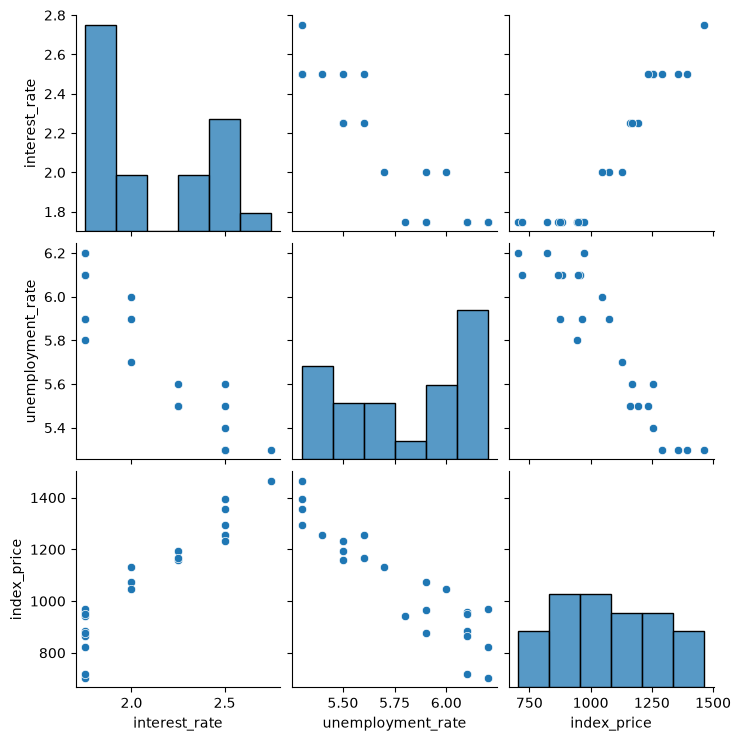

In [12]:
sns.pairplot(df_index)

In [13]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment rate')

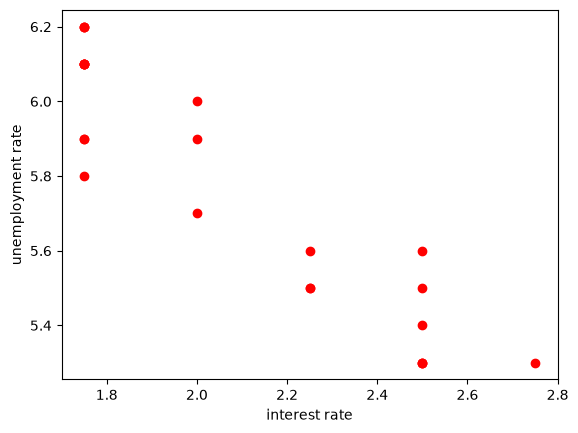

In [15]:
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'], color = 'red')
plt.xlabel("interest rate")
plt.ylabel("unemployment rate")

In [25]:
# independent and dependent feature
X = df_index[["interest_rate","unemployment_rate"]]
Y = df_index["index_price"]

In [26]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.2, random_state = 42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

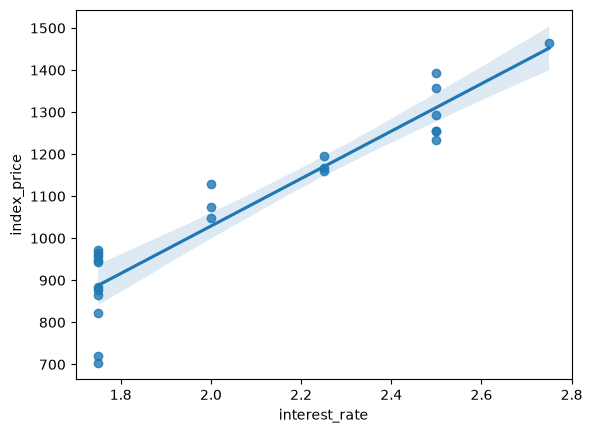

In [28]:
sns.regplot(data=df_index, 
    x="interest_rate", 
    y="index_price", )

In [29]:
# stander scaling
from sklearn.preprocessing import StandardScaler


In [50]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [63]:
X_test

array([[ 0.40089186, -0.8660254 ],
       [-0.93541435,  1.15470054],
       [ 1.73719807, -1.44337567],
       [-0.93541435,  0.8660254 ],
       [-0.26726124,  0.28867513]])

In [52]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [54]:
regression.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 86.63,-114.05]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1059
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[6.04,1.25]"


In [55]:
print("coefficient or slop:", regression.coef_)
print("Intercept:",regression.intercept_)


coefficient or slop: [  86.63351334 -114.04857249]
Intercept: 1059.421052631579


In [56]:
# cross validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(regression, X_train, Y_train, cv=3)

In [57]:
np.mean(scores)

np.float64(0.8543405270172677)

In [58]:
# prediction
Y_pred = regression.predict(X_test)

In [59]:
Y_pred

array([1192.92068422,  846.6908733 , 1374.53556008,  879.61386031,
       1003.34428525])

In [60]:
## Performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
MSE = mean_squared_error(Y_test, Y_pred)
MAE = mean_absolute_error(Y_test,Y_pred)
RMSE = np.sqrt(MSE)
print(MSE)
print(MAE)
print(RMSE)

5952.207497480513
64.74722105636553
77.15055085662391


In [62]:
from sklearn.metrics import r2_score, adjusted_rand_score
r2 = r2_score(Y_test,Y_pred)
print(r2)
adjusted_r2 = adjusted_rand_score(Y_test,Y_pred)
print(adjusted_r2)

0.8507000324705947
1.0


c:\My_Learning\ML_Learning\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received multiclass values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


Assumption

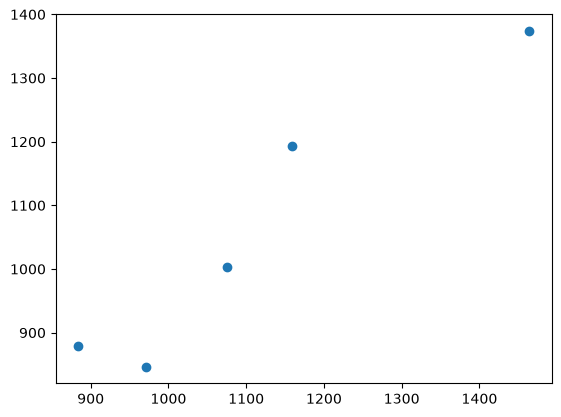

In [46]:
plt.scatter(Y_test,Y_pred)

In [47]:
residuals = Y_test - Y_pred
print(residuals)

8     -33.920684
16    124.309127
0      89.464440
18      4.386140
11     71.655715
Name: index_price, dtype: float64


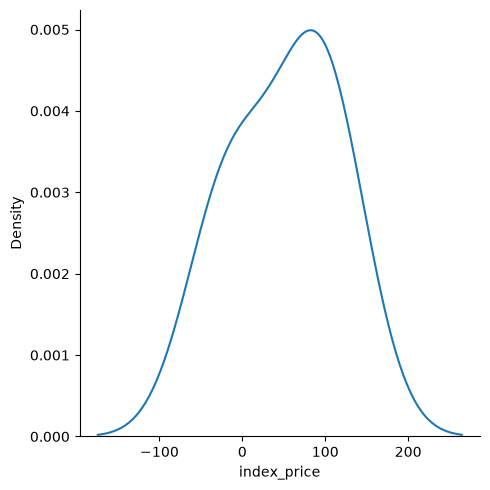

In [48]:
sns.displot(residuals,kind="kde")

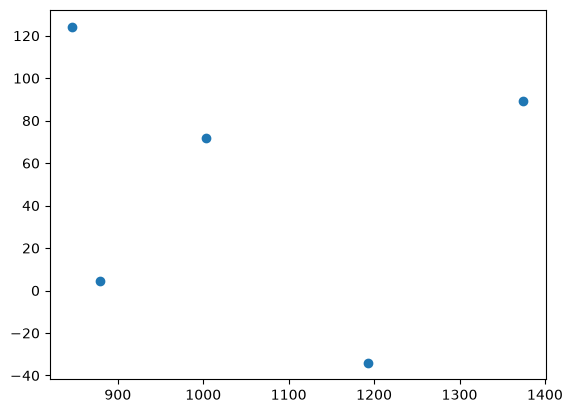

In [49]:
plt.scatter(Y_pred,residuals)